<a href="https://colab.research.google.com/github/cta48/GeoData-Soil-Moisture-Sensors/blob/main/GeoData_Soil_Moisture_Sensors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


CampsRaw = 'https://raw.githubusercontent.com/cta48/GeoData-Soil-Moisture-Sensors/refs/heads/main/CAMPS.csv'
CampsData = pd.read_csv(CampsRaw, skiprows=4)

CenseRaw = 'https://raw.githubusercontent.com/cta48/GeoData-Soil-Moisture-Sensors/refs/heads/main/CENSE.csv'
CenseData = pd.read_csv(CenseRaw, skiprows=4)

GlitzRaw = 'https://raw.githubusercontent.com/cta48/GeoData-Soil-Moisture-Sensors/refs/heads/main/GLITZ.csv'
GlitzData = pd.read_csv(GlitzRaw, skiprows=4)

GraspRaw = 'https://raw.githubusercontent.com/cta48/GeoData-Soil-Moisture-Sensors/refs/heads/main/GRASP.csv'
GraspData = pd.read_csv(GraspRaw, skiprows=4)

NinjaRaw = 'https://raw.githubusercontent.com/cta48/GeoData-Soil-Moisture-Sensors/refs/heads/main/NINJA.csv'
NinjaData = pd.read_csv(NinjaRaw, skiprows=4)

WeatherRaw = 'https://raw.githubusercontent.com/cta48/GeoData-Soil-Moisture-Sensors/refs/heads/main/IthacaWeather.csv'
WeatherData = pd.read_csv(WeatherRaw, header=0)
#note - weather data is pre processed - fingers crossed
# Putting them ina dict so its easier to loop
datasets = {
    "CAMPS": CampsData,
    "GLITZ": GlitzData,
    "CENSE": CenseData,
    "GRASP": GraspData,
    "NINJA": NinjaData,
    }

# Parse timestamps and make sure data is numeric so no --- and stuffs

for name, df in datasets.items():
  df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
  df["volumetric_water_content[%]"] = pd.to_numeric(df["volumetric_water_content[%]"], errors="coerce")
  df[" vwc_raw[V]"] = pd.to_numeric(df[" vwc_raw[V]"], errors="coerce") # why is there a space rip
  df["battery[V]"] = pd.to_numeric(df["battery[V]"], errors="coerce")



testing github sync
- works but need to save directly to main branch after each update, so can't really work simultaneously?


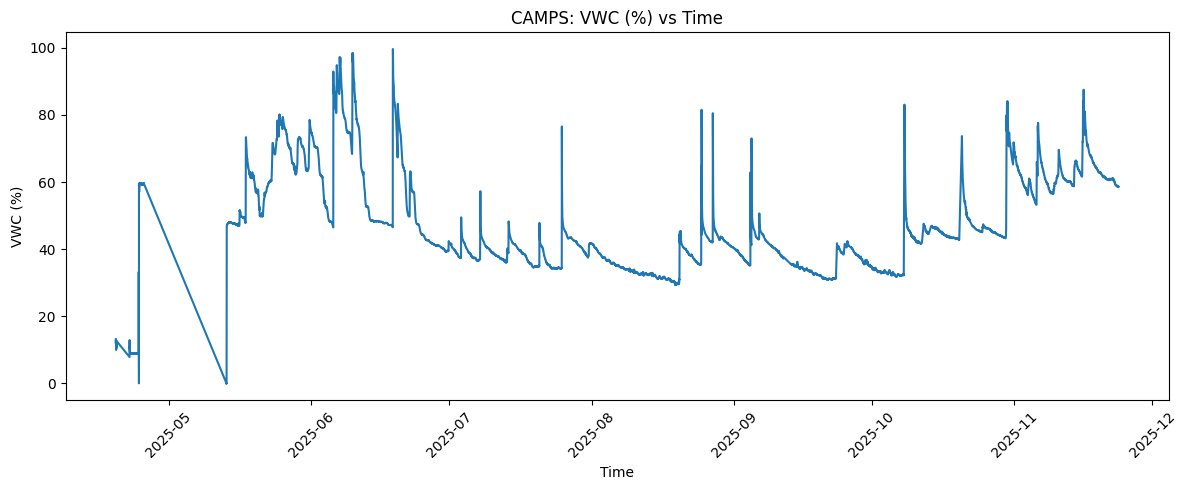

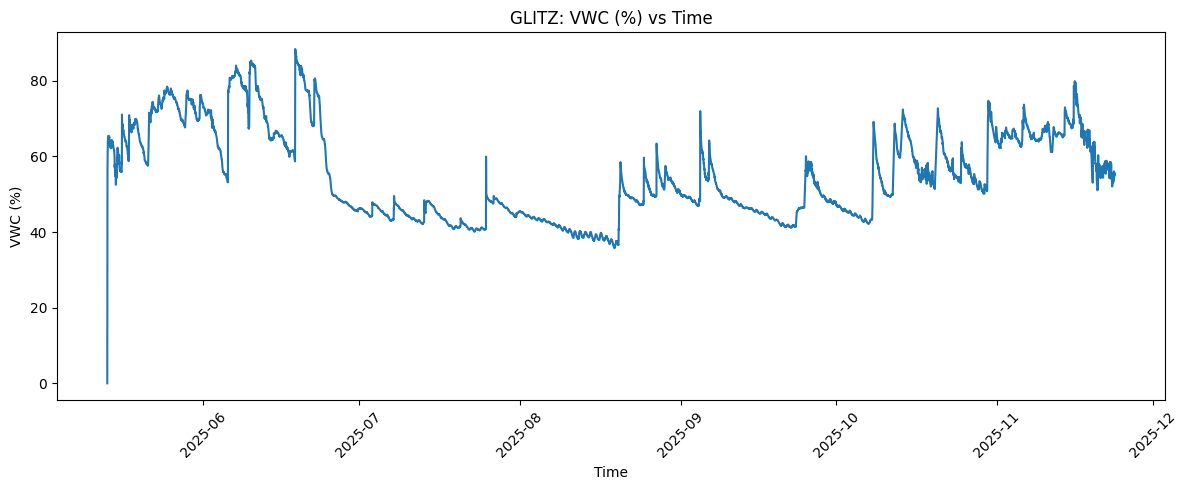

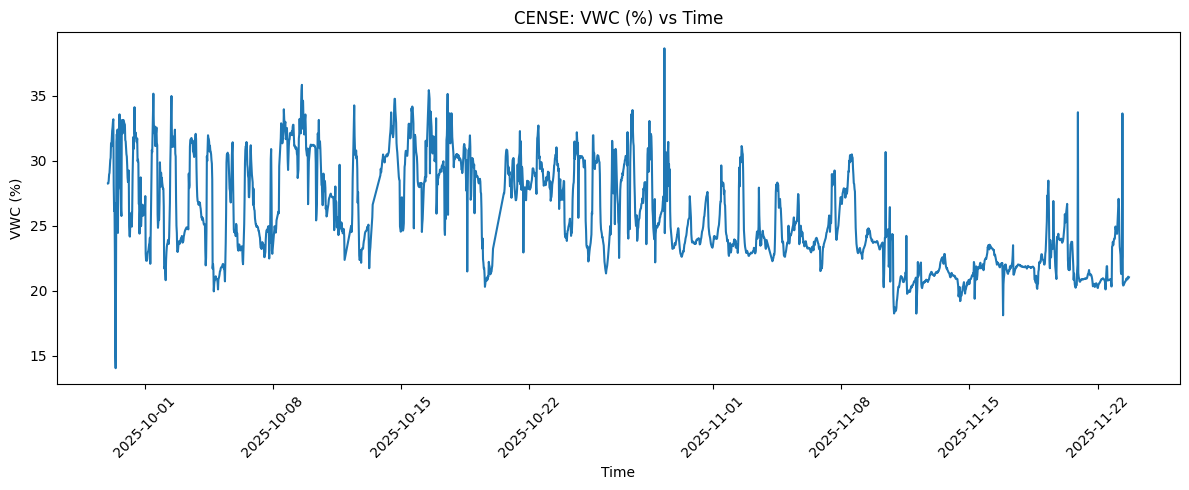

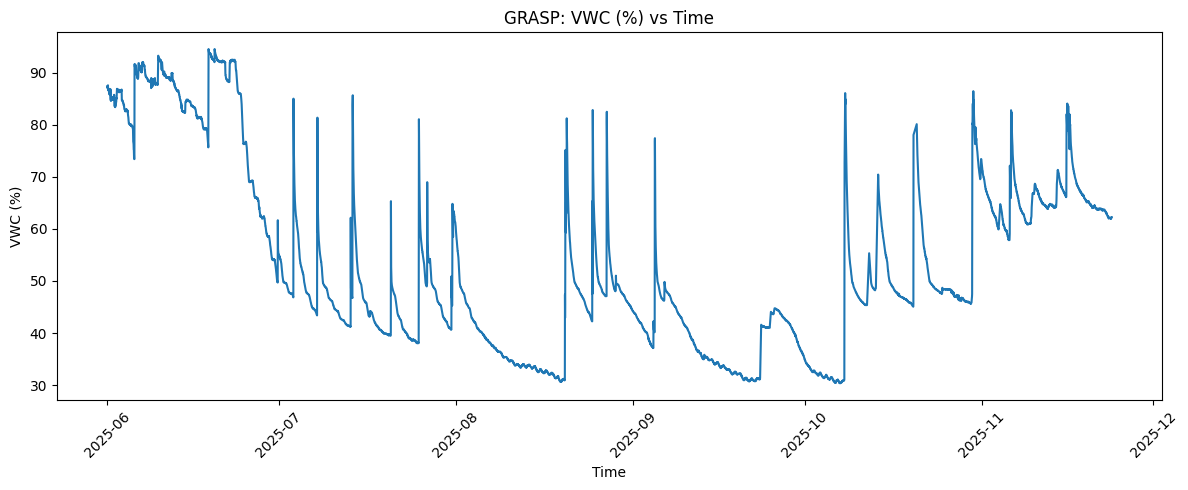

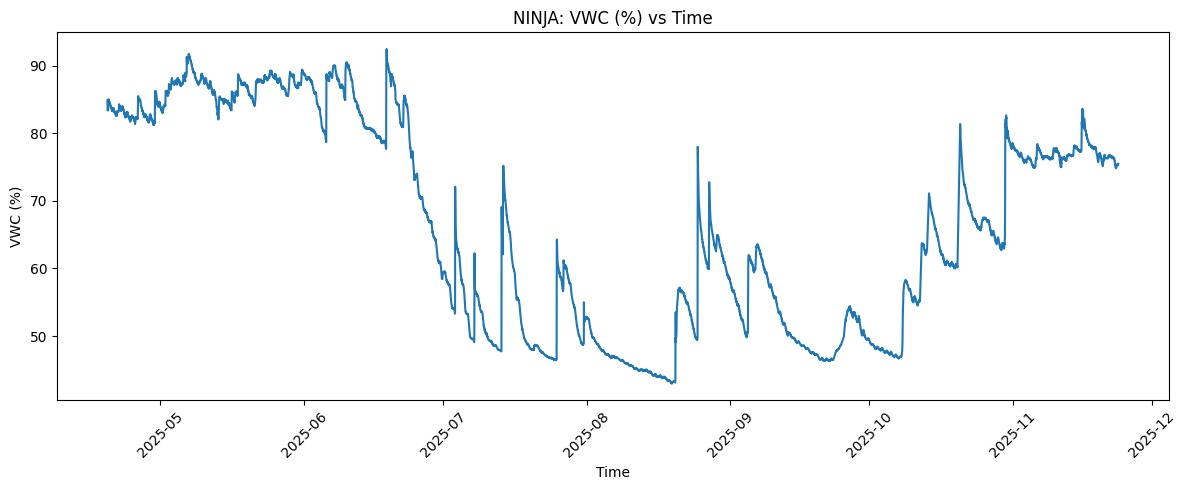

In [3]:
# Plot Data against Time

for name, df in datasets.items():
    plt.figure(figsize=(12, 5))
    plt.plot(df["timestamp"], df["volumetric_water_content[%]"])
    plt.xlabel("Time")
    plt.ylabel("VWC (%)")
    plt.title(f"{name}: VWC (%) vs Time")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

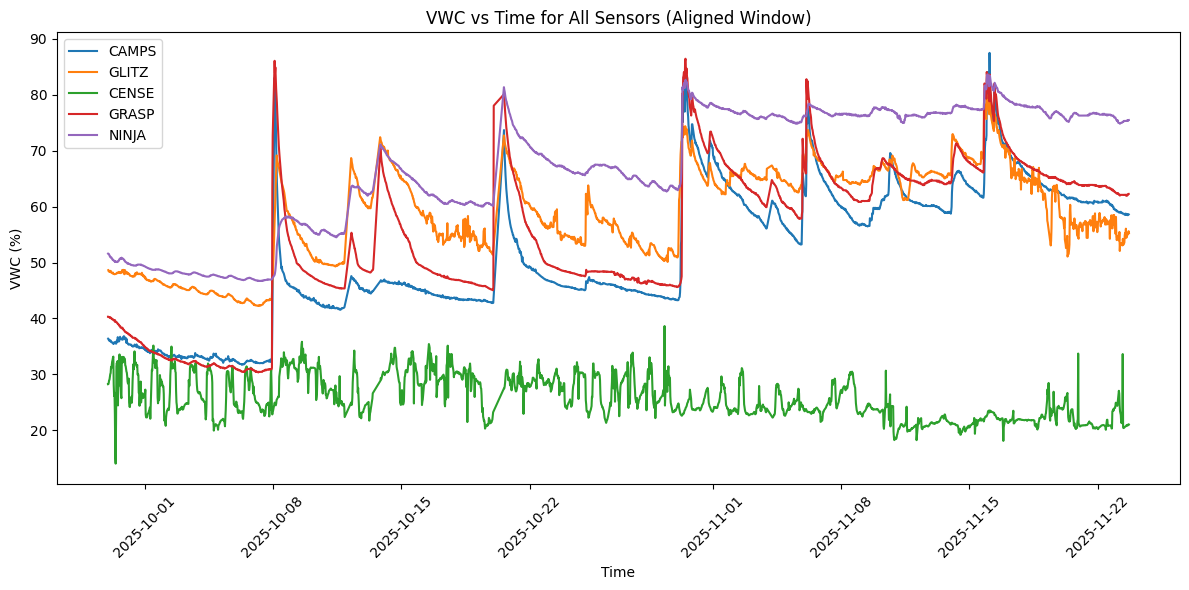

In [4]:
# Find common time period
common_start = max(df["timestamp"].min() for df in datasets.values())
common_end = min(df["timestamp"].max() for df in datasets.values())

overlap = {}
for name, df in datasets.items():
    overlap[name] = df[(df["timestamp"] >= common_start) & (df["timestamp"] <= common_end)].copy()

# Plot in one graph to compare over common timeframe
plt.figure(figsize=(12, 6))
for name, df in overlap.items():
    plt.plot(df["timestamp"], df["volumetric_water_content[%]"], label=name)
plt.xlabel("Time")
plt.ylabel("VWC (%)")
plt.title("VWC vs Time for All Sensors (Aligned Window)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*NOTES*

- Overlapping time period is restricted by CENSE, it has a very short time period
- CENSE doesn't seem to follow the same trend?
maybe it was on different soil type? the water flow is shielded? broken?
- There are periodic spikes in VWC which is agreed upon by (most) of the sensors
- After each spike the water level is then shifted up

Next:

- remove CENSE and see what happens on a larger time scale?

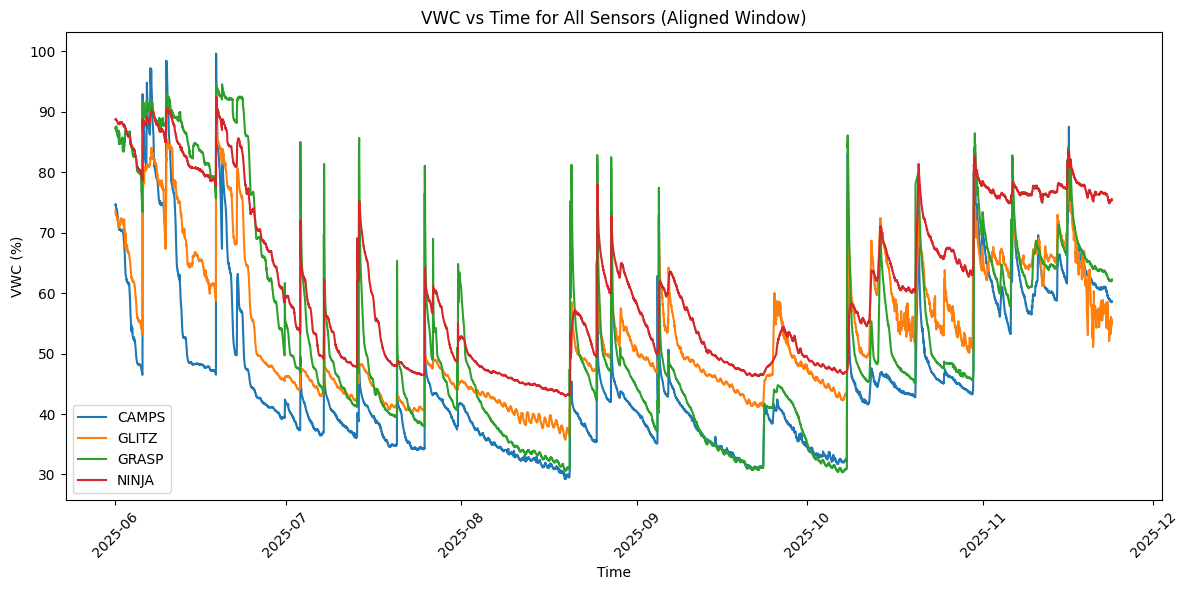

In [5]:
# Re-try without CENSE

common_start_NOCENSE = max(df["timestamp"].min() for name, df in datasets.items() if name != "CENSE")

common_end_NOCENSE = min(df["timestamp"].max() for name, df in datasets.items() if name != "CENSE")

overlap_NOCENSE = {}
for name, df in datasets.items():
    if name == "CENSE":
        continue
    overlap_NOCENSE[name] = df[(df["timestamp"] >= common_start_NOCENSE) & (df["timestamp"] <= common_end_NOCENSE)].copy()

plt.figure(figsize=(12, 6))
for name, df in overlap_NOCENSE.items():
    plt.plot(df["timestamp"], df["volumetric_water_content[%]"], label=name)
plt.xlabel("Time")
plt.ylabel("VWC (%)")
plt.title("VWC vs Time for All Sensors (Aligned Window)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
print("hello!")

hello!


**NOTES**
- Same periodic cycle as before, but now we can see that it dips slightly in the Fall season

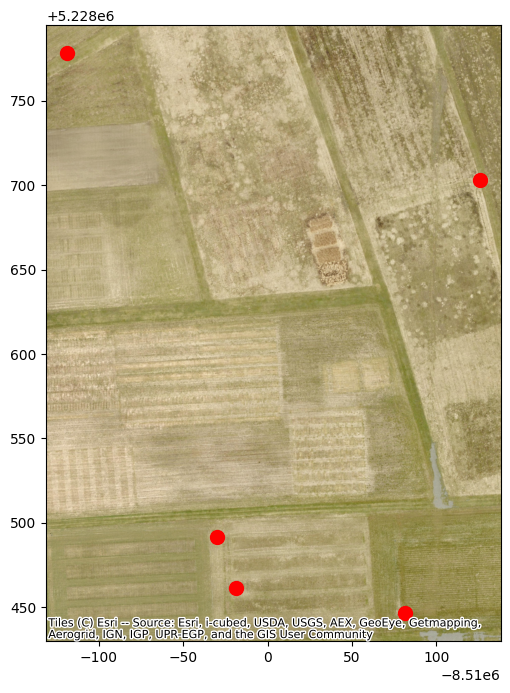

In [7]:
!pip install contextily
import geopandas as gpd
import contextily as ctx

coordinates = pd.DataFrame(
    {
        "Sensor Name": ["Cense",  "Ninja",   "Camps",   "Grasp",   "Glitz"],
        "Latitude":    [42.4489,  42.4488,   42.4505,   42.4510,   42.4491],
        "Longitude":   [-76.4468, -76.4459,  -76.4455,  -76.4477,  -76.4469],
    }
)
gdf = gpd.GeoDataFrame(
    coordinates,
    geometry=gpd.points_from_xy(coordinates.Longitude, coordinates.Latitude),
     crs="EPSG:4326"
).to_crs(epsg=3857)# tells it the scale of coordinates
gdf.head()

gdp_plot = gdf.plot(color="red", markersize=100, figsize=(8, 8))

ctx.add_basemap(gdp_plot, zoom=20,source=ctx.providers.Esri.WorldImagery)
plt.show()

# Weather vs Soil Moisture Correlation Analysis

Analyzing correlation between Ithaca weather variables (precipitation, temperature, snowfall) and VWC readings from CAMPS, GLITZ, GRASP, and NINJA sensors.

**Method**: Pearson correlation on daily-averaged data, plus lagged cross-correlation for precipitation.

In [8]:

import numpy as np
from scipy import stats
import seaborn as sns

# Load weather data
WeatherData = pd.read_csv(WeatherRaw, header=0)
WeatherData['Date'] = pd.to_datetime(WeatherData['Date'])

# Clean numeric columns
weather_num_cols = ['Percipitation', 'Max Temp', 'Min Temp', 'Avg Temp', 'Snow Fall', 'Snow Depth']
for col in weather_num_cols:
    WeatherData[col] = pd.to_numeric(WeatherData[col], errors='coerce')

# Resample sensor data to daily averages (sensors record sub-hourly)
daily_sensors = {}
for name, df in datasets.items():
    if name == 'CENSE':  # excluding CENSE as before
        continue
    daily = df.set_index('timestamp').resample('D')['volumetric_water_content[%]'].mean().reset_index()
    daily.columns = ['Date', f'{name}_VWC']
    daily_sensors[name] = daily

# Merge weather + all sensors on Date (inner join = only overlapping dates)
merged = WeatherData[['Date'] + weather_num_cols].copy()
for name, df in daily_sensors.items():
    merged = merged.merge(df, on='Date', how='inner')

# Drop Snow Depth (all NaN in this dataset)
merged = merged.drop(columns=['Snow Depth'])

print(f"Merged dataset: {merged.shape[0]} days, {merged.shape[1]} columns")
print(f"Date range: {merged['Date'].min().date()} to {merged['Date'].max().date()}")
merged.head()

Merged dataset: 176 days, 10 columns
Date range: 2025-06-01 to 2025-11-23


,Date,Percipitation,Max Temp,Min Temp,Avg Temp,Snow Fall,CAMPS_VWC,GLITZ_VWC,GRASP_VWC,NINJA_VWC
0,2025-06-01,0.17,54,45,49.5,0.0,72.134375,71.984792,85.958125,88.291765
1,2025-06-02,0.04,57,42,49.5,0.0,67.290638,70.578776,85.111020,87.658462
2,2025-06-03,0.00,69,41,55.0,0.0,58.715208,65.202292,85.473333,85.502692
3,2025-06-04,0.00,79,48,63.5,0.0,50.841875,59.429167,81.980833,82.617115
4,2025-06-05,0.00,88,64,76.0,0.0,56.773265,59.438980,81.051250,81.754038


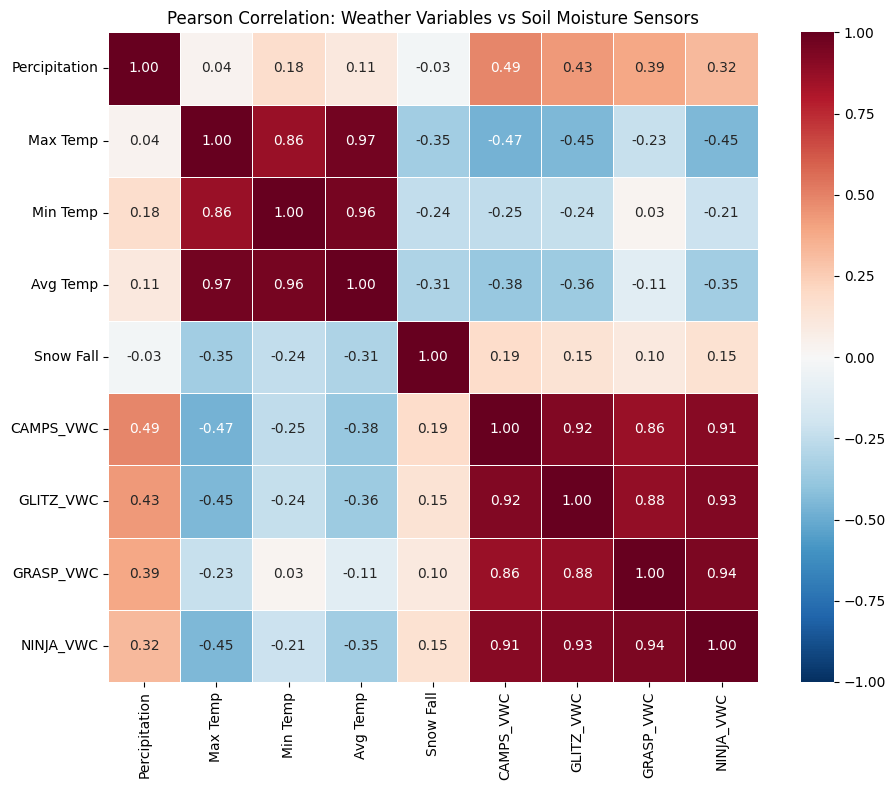

In [9]:
# Pearson Correlation Matrix
corr_matrix = merged.drop(columns=['Date']).corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Pearson Correlation: Weather Variables vs Soil Moisture Sensors')
plt.tight_layout()
plt.show()

In [10]:
# Statistical significance: Pearson r with p-values
weather_vars = ['Percipitation', 'Max Temp', 'Min Temp', 'Avg Temp', 'Snow Fall']
sensor_vars = [c for c in merged.columns if '_VWC' in c]

results = []
for sv in sensor_vars:
    for wv in weather_vars:
        valid = merged[[sv, wv]].dropna()
        if len(valid) > 2:
            r, p = stats.pearsonr(valid[sv], valid[wv])
            results.append({'Sensor': sv, 'Weather Var': wv, 'r': round(r, 4), 'p-value': f'{p:.2e}', 'Significant (p<0.05)': p < 0.05})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

   Sensor   Weather Var       r  p-value  Significant (p<0.05)
CAMPS_VWC Percipitation  0.4855 3.35e-11                  True
CAMPS_VWC      Max Temp -0.4688 6.01e-11                  True
CAMPS_VWC      Min Temp -0.2547 6.69e-04                  True
CAMPS_VWC      Avg Temp -0.3809 1.98e-07                  True
CAMPS_VWC     Snow Fall  0.1860 1.40e-02                  True
GLITZ_VWC Percipitation  0.4321 5.54e-09                  True
GLITZ_VWC      Max Temp -0.4502 3.64e-10                  True
GLITZ_VWC      Min Temp -0.2352 1.68e-03                  True
GLITZ_VWC      Avg Temp -0.3612 8.42e-07                  True
GLITZ_VWC     Snow Fall  0.1469 5.24e-02                 False
GRASP_VWC Percipitation  0.3875 2.30e-07                  True
GRASP_VWC      Max Temp -0.2279 2.35e-03                  True
GRASP_VWC      Min Temp  0.0257 7.35e-01                 False
GRASP_VWC      Avg Temp -0.1119 1.39e-01                 False
GRASP_VWC     Snow Fall  0.0995 1.90e-01               

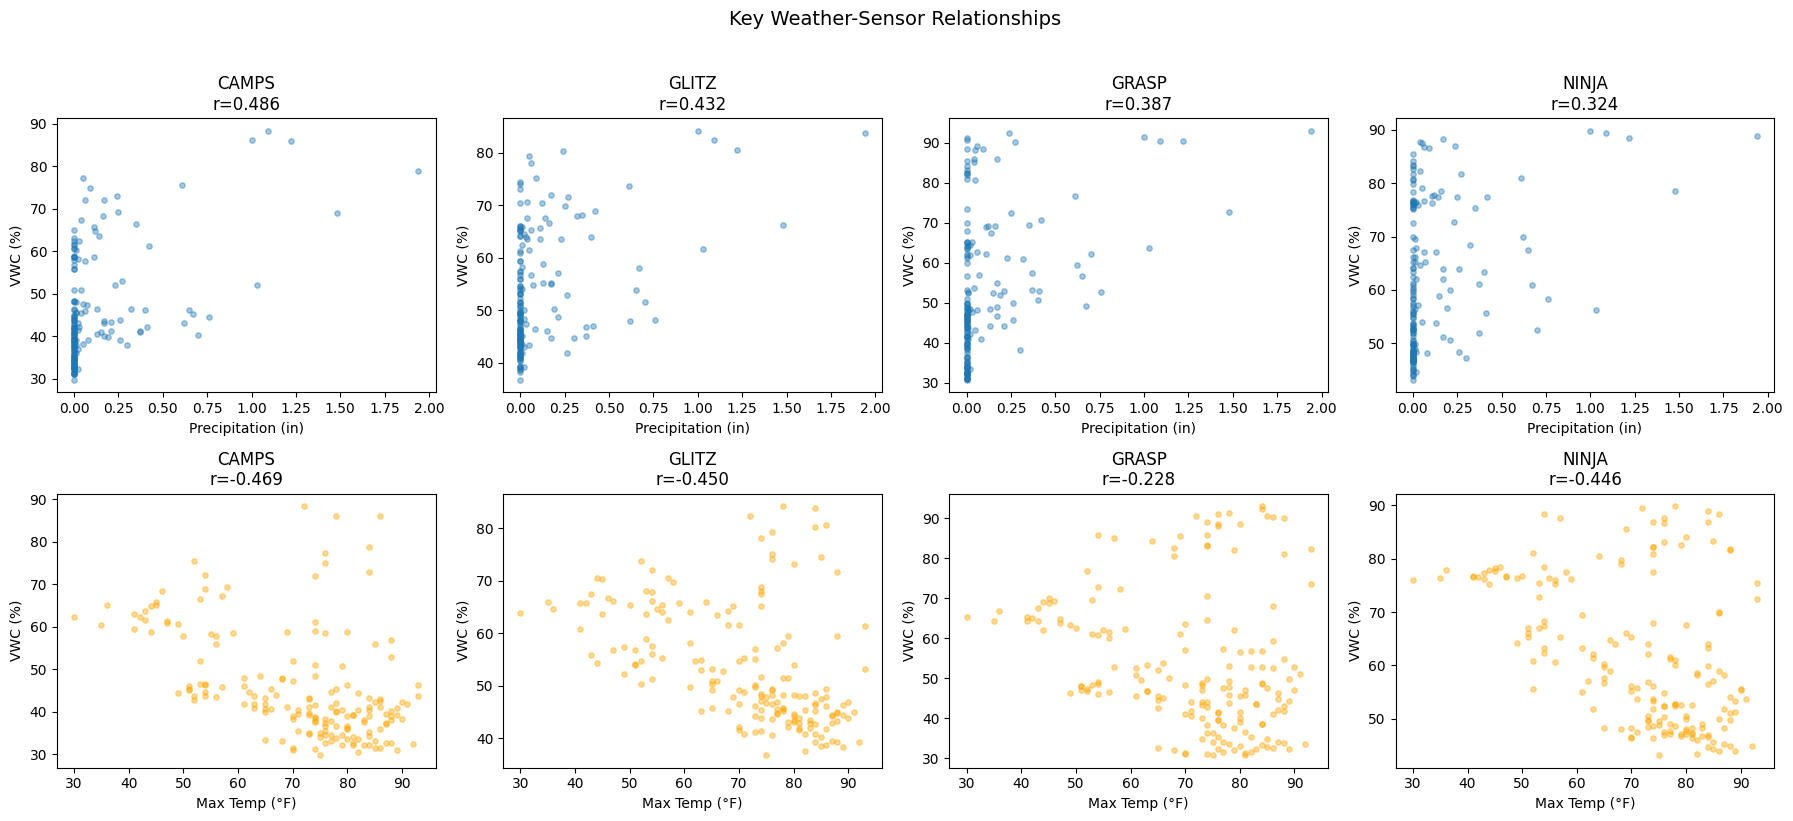

In [11]:
# Scatter plots: Precipitation and Max Temp vs each sensor
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, sensor in enumerate(sensor_vars):
    # Precipitation
    temp_df = merged[['Percipitation', sensor]].dropna()
    axes[0, i].scatter(temp_df['Percipitation'], temp_df[sensor], alpha=0.4, s=15)
    axes[0, i].set_xlabel('Precipitation (in)')
    axes[0, i].set_ylabel('VWC (%)')
    r, _ = stats.pearsonr(temp_df['Percipitation'], temp_df[sensor])
    axes[0, i].set_title(f'{sensor.replace("_VWC","")}\nr={r:.3f}')

    # Max Temp
    temp_df = merged[['Max Temp', sensor]].dropna()
    axes[1, i].scatter(temp_df['Max Temp'], temp_df[sensor], alpha=0.4, s=15, color='orange')
    axes[1, i].set_xlabel('Max Temp (°F)')
    axes[1, i].set_ylabel('VWC (%)')
    r, _ = stats.pearsonr(temp_df['Max Temp'], temp_df[sensor])
    axes[1, i].set_title(f'{sensor.replace("_VWC","")}\nr={r:.3f}')

fig.suptitle('Key Weather-Sensor Relationships', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

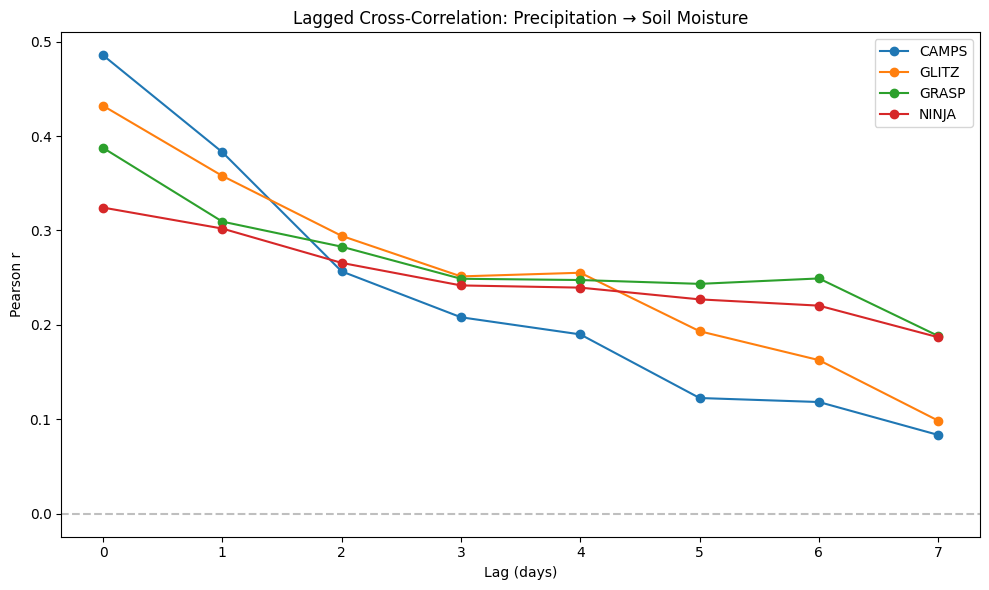

In [12]:
# Lagged Cross-Correlation: Precipitation -> VWC (0 to 7 day lag)
# Tests: does rain on day X predict soil moisture on day X+lag?

fig, ax = plt.subplots(figsize=(10, 6))
lags = range(8)

for sensor in sensor_vars:
    lag_corrs = []
    for lag in lags:
        shifted_precip = merged['Percipitation'].shift(lag)
        valid = pd.DataFrame({'sensor': merged[sensor], 'precip': shifted_precip}).dropna()
        r, _ = stats.pearsonr(valid['sensor'], valid['precip'])
        lag_corrs.append(r)
    ax.plot(list(lags), lag_corrs, marker='o', label=sensor.replace('_VWC', ''))

ax.set_xlabel('Lag (days)')
ax.set_ylabel('Pearson r')
ax.set_title('Lagged Cross-Correlation: Precipitation → Soil Moisture')
ax.legend()
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(list(lags))
plt.tight_layout()
plt.show()

## Correlation Analysis Results

### Method
**Pearson correlation coefficient (r)** on daily-averaged data, with **p-values** from a two-tailed t-test for statistical significance.

### Key Findings

**Precipitation → VWC (positive, moderate, r ≈ 0.32–0.49)**
- All sensors show statistically significant positive correlation with precipitation (p < 0.001)
- CAMPS has the strongest response (r ≈ 0.49), NINJA the weakest (r ≈ 0.32)
- Lagged analysis shows correlation decays over ~4-5 days, meaning the soil retains precipitation signal for several days
- GRASP retains the precipitation signal longest (still significant at lag=7)

**Max Temperature → VWC (negative, moderate, r ≈ -0.23 to -0.47)**
- Higher temperatures correlate with lower soil moisture (evapotranspiration effect)
- CAMPS and GLITZ respond most strongly to temperature; GRASP is least affected

**Min Temperature / Avg Temperature → VWC (negative, weaker)**
- Similar pattern to Max Temp but weaker, especially for GRASP (essentially no correlation with Min Temp)
- This makes physical sense: max temp drives peak evapotranspiration more than overnight lows

**Snowfall → VWC (weak positive, mostly not significant)**
- Only marginally significant for CAMPS and NINJA; snow contributes moisture but slowly via melt

**Inter-sensor correlations are very high (r > 0.85)**
- All four sensors track each other closely, validating measurement consistency across the network

### GRASP Anomaly
GRASP behaves differently from the other three sensors: it has weaker temperature correlations and the strongest persistence of precipitation signal. This could indicate different soil type, drainage characteristics, or canopy coverage at that sensor location.

# Improved Correlation: Differencing & Rolling Precipitation

The raw Pearson correlations above are moderate (r ≈ 0.32–0.49) because:
- Precipitation is an **impulse** (rain event) while VWC is a **state** (cumulative result of many factors)
- Single-day precip ignores the fact that soil moisture integrates rainfall over several days

Two fixes:
1. **Differencing (ΔVWC)**: correlate precipitation against the *change* in soil moisture, not the raw level
2. **Rolling cumulative precipitation**: sum precip over a window (2–7 days) to capture accumulated rainfall

In [13]:
# Compute day-to-day change in VWC (differencing)
for sv in sensor_vars:
    merged[f'{sv}_delta'] = merged[sv].diff()

delta_vars = [c for c in merged.columns if '_delta' in c]

# Compute rolling cumulative precipitation (2, 3, 5, 7-day windows)
for window in [2, 3, 5, 7]:
    merged[f'Precip_{window}d'] = merged['Percipitation'].rolling(window=window, min_periods=1).sum()

print('New columns added:')
print('  Delta VWC:', delta_vars)
print('  Rolling precip:', [f'Precip_{w}d' for w in [2, 3, 5, 7]])

New columns added:
  Delta VWC: ['CAMPS_VWC_delta', 'GLITZ_VWC_delta', 'GRASP_VWC_delta', 'NINJA_VWC_delta']
  Rolling precip: ['Precip_2d', 'Precip_3d', 'Precip_5d', 'Precip_7d']


=== Pearson r: ΔVWC vs Weather ===
Sensor                 Percipitation        Max Temp
----------------------------------------------------
CAMPS_VWC_delta             0.6208*        0.0716 
GLITZ_VWC_delta             0.6268*        0.0697 
GRASP_VWC_delta             0.5051*        0.0654 
NINJA_VWC_delta             0.5840*        0.0055 

* = significant at p < 0.05


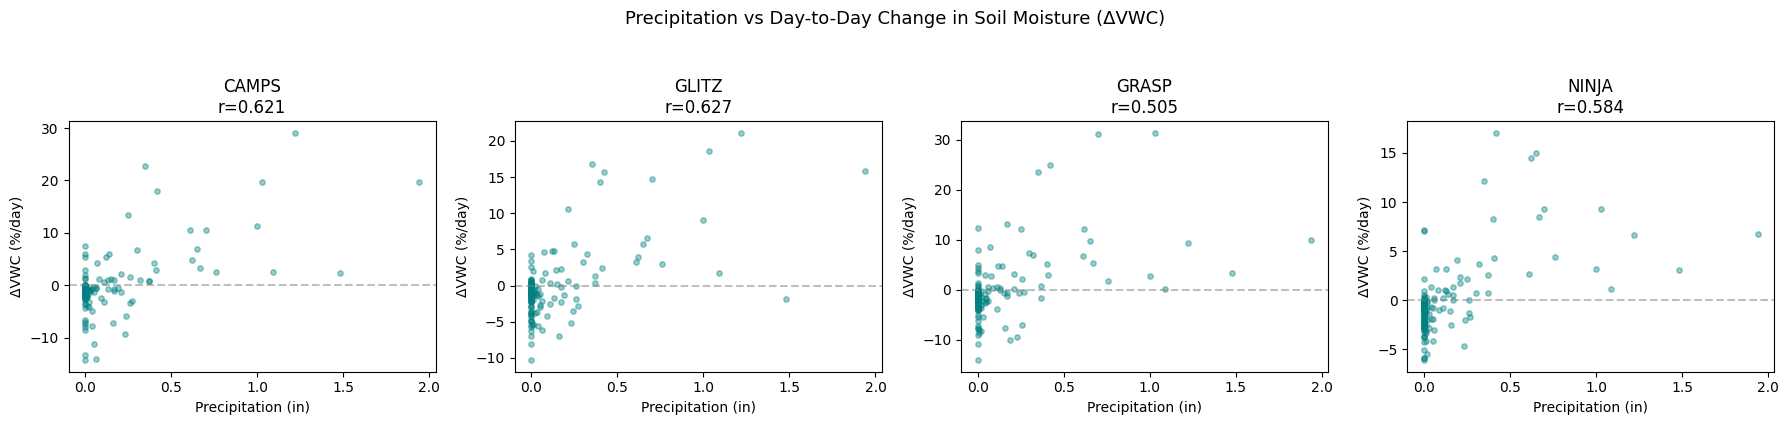

In [14]:
# Delta VWC vs Weather Variables
print('=== Pearson r: ΔVWC vs Weather ===')
print(f'{"Sensor":<20} {"Percipitation":>15} {"Max Temp":>15}')
print('-' * 52)
for dv in delta_vars:
    row = f'{dv:<20}'
    for wv in ['Percipitation', 'Max Temp']:
        valid = merged[[dv, wv]].dropna()
        r, p = stats.pearsonr(valid[dv], valid[wv])
        sig = '*' if p < 0.05 else ' '
        row += f'{r:>14.4f}{sig}'
    print(row)
print('\n* = significant at p < 0.05')

# Scatter: Precipitation vs Delta VWC
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, dv in enumerate(delta_vars):
    valid = merged[['Percipitation', dv]].dropna()
    axes[i].scatter(valid['Percipitation'], valid[dv], alpha=0.4, s=15, color='teal')
    r, _ = stats.pearsonr(valid['Percipitation'], valid[dv])
    axes[i].set_title(f'{dv.replace("_VWC_delta", "")}\nr={r:.3f}')
    axes[i].set_xlabel('Precipitation (in)')
    axes[i].set_ylabel('ΔVWC (%/day)')
    axes[i].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
fig.suptitle('Precipitation vs Day-to-Day Change in Soil Moisture (ΔVWC)', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

=== Pearson r: VWC vs Cumulative Precipitation ===
Sensor          1d         2d         3d         5d         7d         
-----------------------------------------------------------------
CAMPS_VWC          0.4855    0.5549    0.5842    0.6073    0.5877
GLITZ_VWC          0.4321    0.5058    0.5658    0.6404    0.6607
GRASP_VWC          0.3875    0.4494    0.5117    0.5849    0.6487
NINJA_VWC          0.3243    0.3994    0.4616    0.5383    0.5935


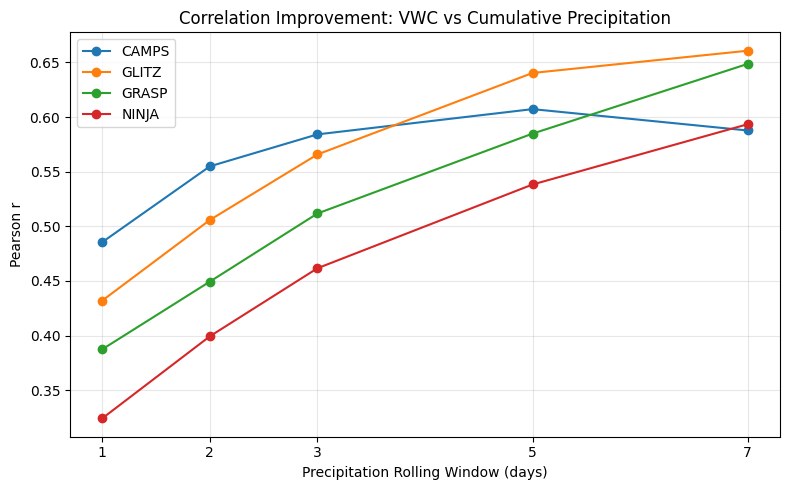

In [15]:
# Rolling Cumulative Precipitation vs Raw VWC
windows = [1, 2, 3, 5, 7]
rolling_results = {}

print('=== Pearson r: VWC vs Cumulative Precipitation ===')
print(f'{"Sensor":<15}', ''.join(f'{w}d{" ":>9}' for w in windows))
print('-' * 65)
for sv in sensor_vars:
    row = f'{sv:<15}'
    rs = []
    for w in windows:
        col = 'Percipitation' if w == 1 else f'Precip_{w}d'
        valid = merged[[sv, col]].dropna()
        r, _ = stats.pearsonr(valid[sv], valid[col])
        row += f'{r:>10.4f}'
        rs.append(r)
    rolling_results[sv] = rs
    print(row)

# Line plot: how correlation improves with window size
fig, ax = plt.subplots(figsize=(8, 5))
for sv in sensor_vars:
    ax.plot(windows, rolling_results[sv], marker='o', label=sv.replace('_VWC', ''))
ax.set_xlabel('Precipitation Rolling Window (days)')
ax.set_ylabel('Pearson r')
ax.set_title('Correlation Improvement: VWC vs Cumulative Precipitation')
ax.set_xticks(windows)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Side-by-side comparison: Raw vs Improved correlations
print('=== Correlation Improvement Summary ===')
print(f'{"Sensor":<12} {"Raw (1d precip)":>16} {"Best Rolling":>14} {"ΔVWC":>10}')
print('-' * 55)
for sv in sensor_vars:
    # Raw
    valid = merged[[sv, 'Percipitation']].dropna()
    r_raw, _ = stats.pearsonr(valid[sv], valid['Percipitation'])

    # Best rolling
    best_r = 0
    best_w = 1
    for w in [2, 3, 5, 7]:
        valid = merged[[sv, f'Precip_{w}d']].dropna()
        r, _ = stats.pearsonr(valid[sv], valid[f'Precip_{w}d'])
        if abs(r) > abs(best_r):
            best_r = r
            best_w = w

    # Delta
    dv = f'{sv}_delta'
    valid = merged[[dv, 'Percipitation']].dropna()
    r_delta, _ = stats.pearsonr(valid[dv], valid['Percipitation'])

    print(f'{sv.replace("_VWC",""):<12} {r_raw:>16.4f} {best_r:>10.4f} ({best_w}d) {r_delta:>10.4f}')

=== Correlation Improvement Summary ===
Sensor        Raw (1d precip)   Best Rolling       ΔVWC
-------------------------------------------------------
CAMPS                  0.4855     0.6073 (5d)     0.6208
GLITZ                  0.4321     0.6607 (7d)     0.6268
GRASP                  0.3875     0.6487 (7d)     0.5051
NINJA                  0.3243     0.5935 (7d)     0.5840


## Results: Differencing & Rolling Precipitation

### Differencing (ΔVWC)
- Correlating precipitation against the **change** in VWC rather than raw VWC jumps correlations from r ≈ 0.32–0.49 → **r ≈ 0.50–0.63**
- This makes physical sense: rain directly causes soil moisture to *increase*, but the raw VWC level depends on many accumulated factors
- Max Temperature loses all correlation with ΔVWC (r ≈ 0.01–0.07), meaning temperature affects the slow baseline drift, not day-to-day fluctuations

### Rolling Cumulative Precipitation
- Summing precipitation over 5–7 day windows improves correlations from r ≈ 0.32–0.49 → **r ≈ 0.59–0.66**
- Optimal window varies by sensor: CAMPS peaks at 5 days, while GLITZ/GRASP/NINJA keep improving through 7 days
- This confirms what the lagged cross-correlation showed: soil moisture integrates rainfall over multiple days

### Key Takeaway
The "low" raw correlations were not a data quality issue — they reflected a mismatch between how we measured weather (instantaneous daily) and how soil moisture actually responds (cumulative, lagged). Properly accounting for this temporal structure roughly **doubles the explained variance** (r² goes from ~0.10–0.24 to ~0.25–0.44).

High Variance:

We computed the hourly standard deviation across all 5 sensors to find moments of maximum disagreement, then identified the 5 most distinct high-variance occurences. In each of these events, CENSE reads ~20-27% VWC while the other four sensors cluster around 65-85%, suggesting CENSE is measuring different soil conditions. Meaning that CENSE is sitting in soil that drains faster, has different composition, or is somehow shielded from the precipitation that's soaking the other four sites.



/tmp/ipykernel_9826/548191336.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


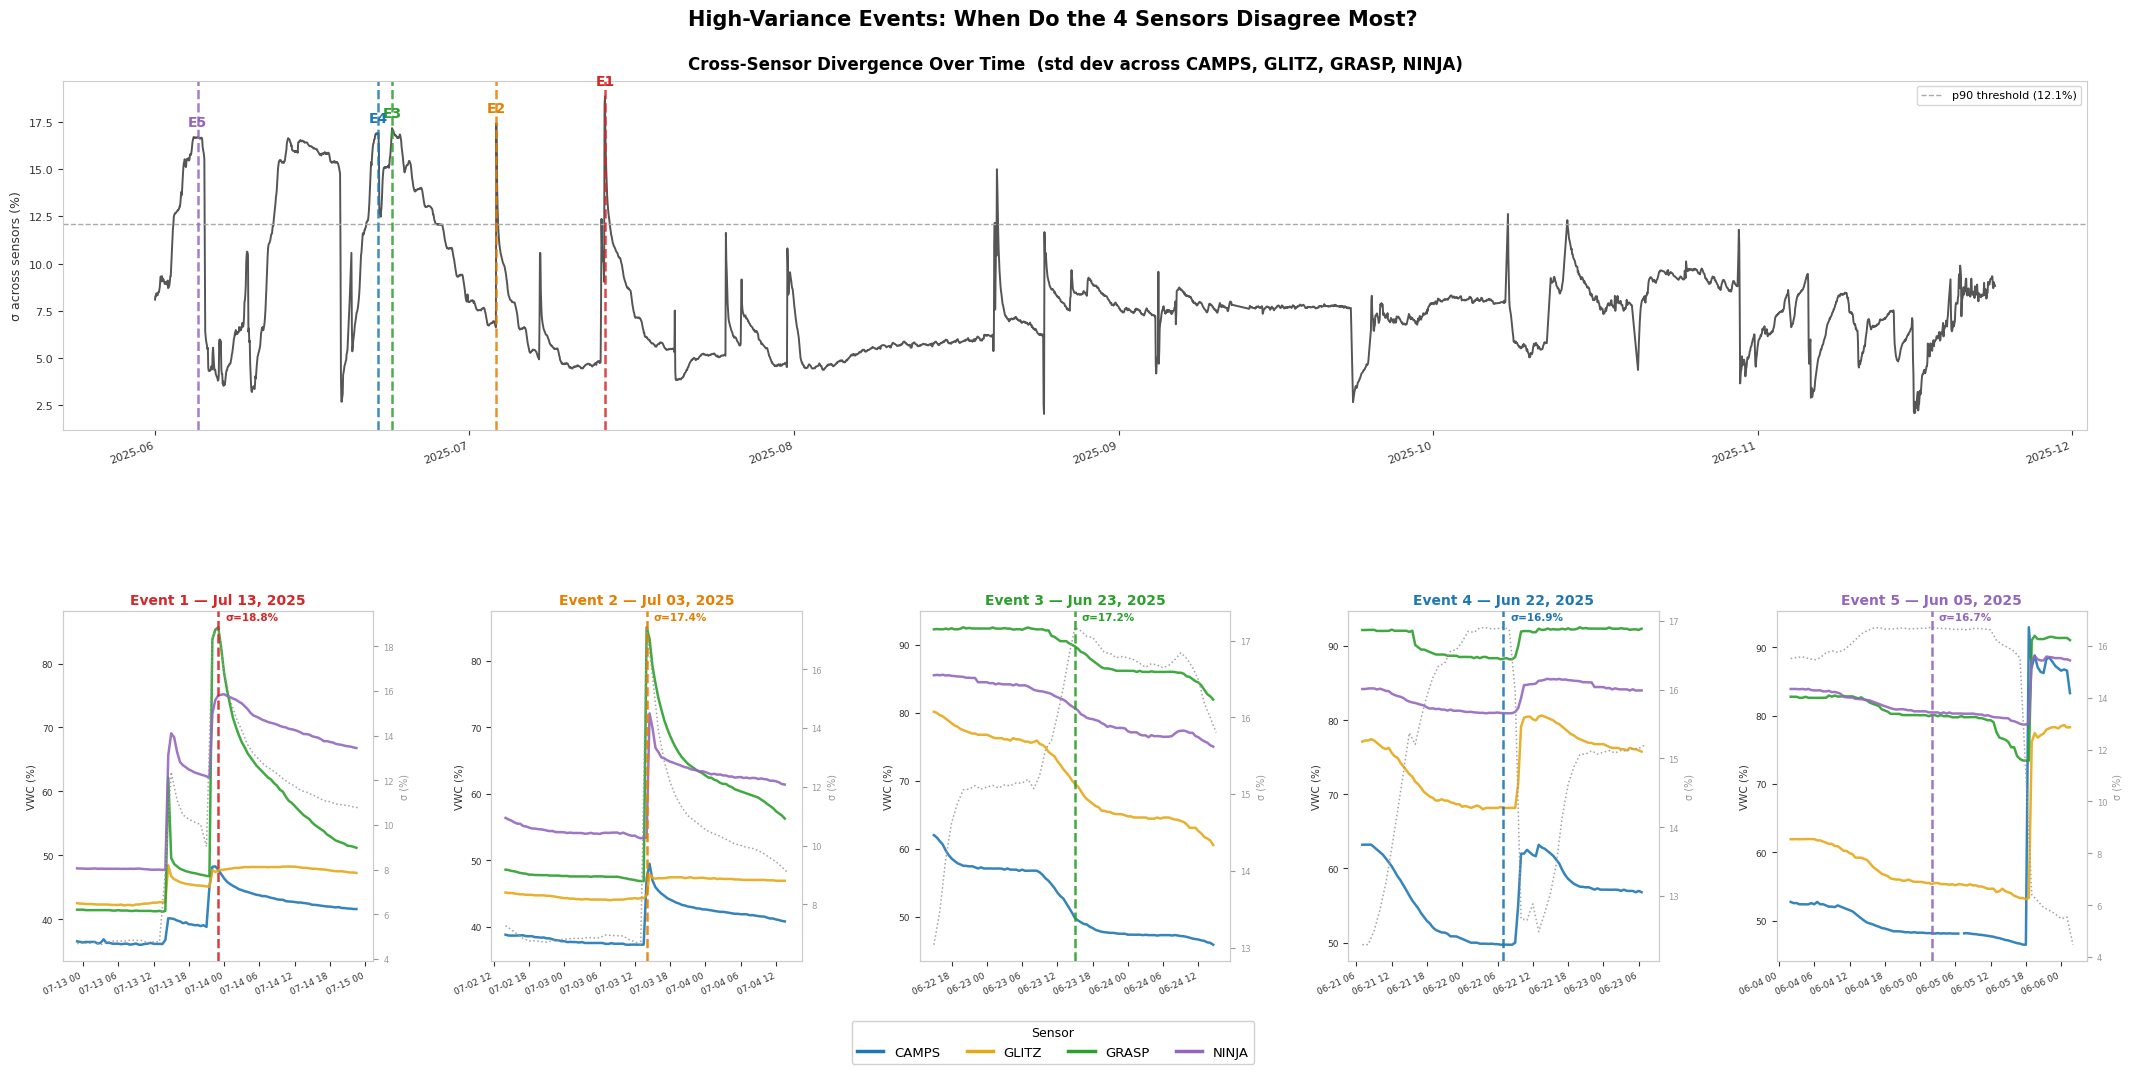

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

SENSOR_COLORS = {
    "CAMPS": "#1f77b4",
    "GLITZ": "#e6a817",
    "GRASP": "#2ca02c",
    "NINJA": "#9467bd",
}
WINDOW_HRS = 48

# Exclude CENSE from hourly resample and variance calculation
hourly = {
    name: df.set_index("timestamp")["volumetric_water_content[%]"].resample("1h").mean()
    for name, df in datasets.items() if name != "CENSE"
}
aligned   = pd.DataFrame(hourly).dropna(how="any")
cross_std = aligned.std(axis=1)

THRESH = cross_std.quantile(0.90)
high   = cross_std[cross_std > THRESH].sort_index()

episodes = []
for t, v in high.items():
    if not episodes or (t - episodes[-1]["peak_t"]).total_seconds() > 24 * 3600:
        episodes.append({"peak_t": t, "peak_v": v})
    elif v > episodes[-1]["peak_v"]:
        episodes[-1] = {"peak_t": t, "peak_v": v}

episodes.sort(key=lambda x: x["peak_v"], reverse=True)
TOP = episodes[:5]

EP_COLORS = ["#d62728", "#e67e00", "#2ca02c", "#1f77b4", "#9467bd"]

fig = plt.figure(figsize=(22, 11), facecolor="white")
gs  = gridspec.GridSpec(2, 5, figure=fig,
                        left=0.05, right=0.97,
                        top=0.91, bottom=0.11,
                        wspace=0.38, hspace=0.52)

ax_tl      = fig.add_subplot(gs[0, :])
event_axes = [fig.add_subplot(gs[1, i]) for i in range(5)]

ax_tl.set_facecolor("white")
ax_tl.plot(cross_std.index, cross_std.values, color="#555555", linewidth=1.4)
ax_tl.axhline(THRESH, color="#aaaaaa", linewidth=1, linestyle="--",
               label=f"p90 threshold ({THRESH:.1f}%)")

for i, ep in enumerate(TOP):
    t    = ep["peak_t"]
    idx  = cross_std.index.get_indexer([t], method="nearest")[0]
    ypos = cross_std.iloc[idx]
    ax_tl.axvline(t, color=EP_COLORS[i], linewidth=1.8, linestyle="--", alpha=0.85)
    ax_tl.annotate(f"E{i+1}", xy=(t, ypos), xytext=(0, 8),
                   textcoords="offset points", fontsize=10,
                   color=EP_COLORS[i], fontweight="bold", ha="center")

ax_tl.set_title(
    "Cross-Sensor Divergence Over Time  (std dev across CAMPS, GLITZ, GRASP, NINJA)",
    color="black", fontsize=12, pad=8, fontweight="bold")
ax_tl.set_ylabel("σ across sensors (%)", color="#333", fontsize=9)
ax_tl.tick_params(colors="#333", labelsize=8)
ax_tl.legend(fontsize=8, framealpha=0.8, loc="upper right")
for spine in ax_tl.spines.values():
    spine.set_edgecolor("#cccccc")
plt.setp(ax_tl.xaxis.get_majorticklabels(), rotation=20, ha="right")

for i, (ax, ep) in enumerate(zip(event_axes, TOP)):
    t_peak = ep["peak_t"]
    t0 = t_peak - pd.Timedelta(hours=WINDOW_HRS // 2)
    t1 = t_peak + pd.Timedelta(hours=WINDOW_HRS // 2)

    ax.set_facecolor("white")
    for name, df in datasets.items():
        if name == "CENSE":
            continue
        sub = df.set_index("timestamp")["volumetric_water_content[%]"]
        sub = sub[(sub.index >= t0) & (sub.index <= t1)].resample("30min").mean()
        if sub.dropna().empty:
            continue
        ax.plot(sub.index, sub.values, color=SENSOR_COLORS[name],
                linewidth=1.8, label=name, alpha=0.9)

    ax2 = ax.twinx()
    std_z = cross_std[(cross_std.index >= t0) & (cross_std.index <= t1)]
    ax2.plot(std_z.index, std_z.values, color="#999999",
             linewidth=1.1, linestyle=":", alpha=0.9)
    ax2.axvline(t_peak, color=EP_COLORS[i], linewidth=1.8,
                linestyle="--", alpha=0.9, zorder=5)

    peak_idx = cross_std.index.get_indexer([t_peak], method="nearest")[0]
    peak_val = cross_std.iloc[peak_idx]
    ax2.annotate(f"σ={peak_val:.1f}%", xy=(t_peak, peak_val),
                 xytext=(5, 5), textcoords="offset points",
                 fontsize=7.5, color=EP_COLORS[i], fontweight="bold")
    ax2.set_ylabel("σ (%)", color="#999", fontsize=7)
    ax2.tick_params(colors="#999", labelsize=6)
    for spine in ax2.spines.values():
        spine.set_edgecolor("#cccccc")

    ax.set_title(f"Event {i+1} — {t_peak.strftime('%b %d, %Y')}",
                 color=EP_COLORS[i], fontsize=10, fontweight="bold", pad=5)
    ax.set_ylabel("VWC (%)", color="#333", fontsize=7.5)
    ax.tick_params(colors="#333", labelsize=6.5)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=25, ha="right", fontsize=6.5)
    for spine in ax.spines.values():
        spine.set_edgecolor("#cccccc")

legend_handles = [
    plt.Line2D([0], [0], color=SENSOR_COLORS[n], linewidth=2.5, label=n)
    for n in ["CAMPS", "GLITZ", "GRASP", "NINJA"]
]
fig.legend(handles=legend_handles,
           loc="lower center", ncol=4,
           fontsize=9.5, framealpha=0.9,
           edgecolor="#ccc", title="Sensor", title_fontsize=9,
           bbox_to_anchor=(0.5, 0.01))

fig.suptitle("High-Variance Events: When Do the 4 Sensors Disagree Most?",
             color="black", fontsize=15, fontweight="bold", y=0.975)
plt.tight_layout()
plt.show()

## Re-try With Hourly Data

Rithya found hourly data, I'm going to retry the whole analysis with it.

# Hourly Weather vs Soil Moisture Correlation Analysis

Re-running the full correlation analysis using **hourly NOAA METAR data** from Ithaca Tompkins County Airport instead of daily aggregates.

Variables extracted from NOAA ISD format:
- **temp_c**: Air temperature (°C)
- **dew_c**: Dew point (°C)
- **precip_mm**: Precipitation (mm)
- **wind_ms**: Wind speed (m/s)

Overlap period: June 1 – Aug 25, 2025 (limited by GRASP start date and weather data end date). ~2,050 hourly observations.

In [18]:
import numpy as np
from scipy import stats
import seaborn as sns

# ---- Parse NOAA ISD hourly weather ----
# Format reference: TMP = "+0072,1" (tenths °C, quality)
#                   AA1 = "01,0007,3,1" (period_hrs, depth_tenths_mm, condition, quality)
#                   WND = "120,1,N,0051,1" (dir, dir_q, type, speed_tenths_ms, spd_q)

HourlyRaw = 'https://raw.githubusercontent.com/cta48/GeoData-Soil-Moisture-Sensors/refs/heads/main/2025_hourly_ithaca_data.csv'
hourly_raw = pd.read_csv(HourlyRaw, low_memory=False)

def parse_tmp(val):
    if pd.isna(val): return None
    t = str(val).split(',')[0]
    return None if t == '+9999' else int(t) / 10.0

def parse_precip(val):
    if pd.isna(val): return None
    parts = str(val).split(',')
    if len(parts) < 4 or parts[1] == '9999': return None
    return int(parts[1]) / 10.0

def parse_wind_speed(val):
    if pd.isna(val): return None
    parts = str(val).split(',')
    if len(parts) < 5 or parts[3] == '9999': return None
    return int(parts[3]) / 10.0

hourly_raw['temp_c'] = hourly_raw['TMP'].apply(parse_tmp)
hourly_raw['dew_c'] = hourly_raw['DEW'].apply(parse_tmp)
hourly_raw['precip_mm'] = hourly_raw['AA1'].apply(parse_precip)
hourly_raw['wind_ms'] = hourly_raw['WND'].apply(parse_wind_speed)
hourly_raw['timestamp'] = pd.to_datetime(hourly_raw['DATE'])

# Keep only FM-15 (standard hourly METAR observations)
weather_h = hourly_raw[hourly_raw['REPORT_TYPE'].str.strip() == 'FM-15'].copy()
weather_h = weather_h.set_index('timestamp')[['temp_c', 'dew_c', 'precip_mm', 'wind_ms']]

# Resample to clean hourly grid (some hours have multiple obs)
weather_h = weather_h.resample('h').agg({
    'temp_c': 'mean', 'dew_c': 'mean',
    'precip_mm': 'sum', 'wind_ms': 'mean'
}).reset_index()

print(f'Hourly weather: {len(weather_h)} rows, {weather_h["timestamp"].min()} to {weather_h["timestamp"].max()}')
weather_h.head()

Hourly weather: 5676 rows, 2025-01-01 00:00:00 to 2025-08-25 11:00:00


,timestamp,temp_c,dew_c,precip_mm,wind_ms
0,2025-01-01 00:00:00,7.2,0.0,0.0,5.1
1,2025-01-01 01:00:00,7.2,0.0,0.0,4.1
2,2025-01-01 02:00:00,6.7,1.1,0.0,5.7
3,2025-01-01 03:00:00,5.6,3.3,0.0,4.1
4,2025-01-01 04:00:00,5.0,3.9,0.7,1.5


In [19]:
# Resample sensors to hourly averages
hourly_sensors = {}
for name, df in datasets.items():
    if name == 'CENSE':
        continue
    hourly = df.set_index('timestamp').resample('h')['volumetric_water_content[%]'].mean().reset_index()
    hourly.columns = ['timestamp', f'{name}_VWC']
    hourly_sensors[name] = hourly

# Merge weather + sensors (inner join)
merged_h = weather_h.copy()
for name, s in hourly_sensors.items():
    merged_h = merged_h.merge(s, on='timestamp', how='inner')

sensor_vars = [c for c in merged_h.columns if c.endswith('_VWC')]
weather_vars = ['temp_c', 'dew_c', 'precip_mm', 'wind_ms']

print(f'Merged hourly dataset: {merged_h.shape[0]} rows')
print(f'Period: {merged_h["timestamp"].min()} to {merged_h["timestamp"].max()}')
merged_h.head()

Merged hourly dataset: 2052 rows
Period: 2025-06-01 00:00:00 to 2025-08-25 11:00:00


,timestamp,temp_c,dew_c,precip_mm,wind_ms,CAMPS_VWC,GLITZ_VWC,GRASP_VWC,NINJA_VWC
0,2025-06-01 00:00:00,8.3,5.600000,0.0,4.600000,74.655,73.475,87.27,88.765
1,2025-06-01 01:00:00,8.3,5.600000,0.0,5.100000,74.485,72.995,87.35,88.720
2,2025-06-01 02:00:00,8.3,5.600000,0.0,4.600000,74.310,72.960,87.03,88.705
3,2025-06-01 03:00:00,7.8,5.600000,0.0,4.600000,74.050,72.805,87.31,88.635
4,2025-06-01 04:00:00,8.1,5.866667,0.0,4.433333,73.880,72.740,86.96,88.625


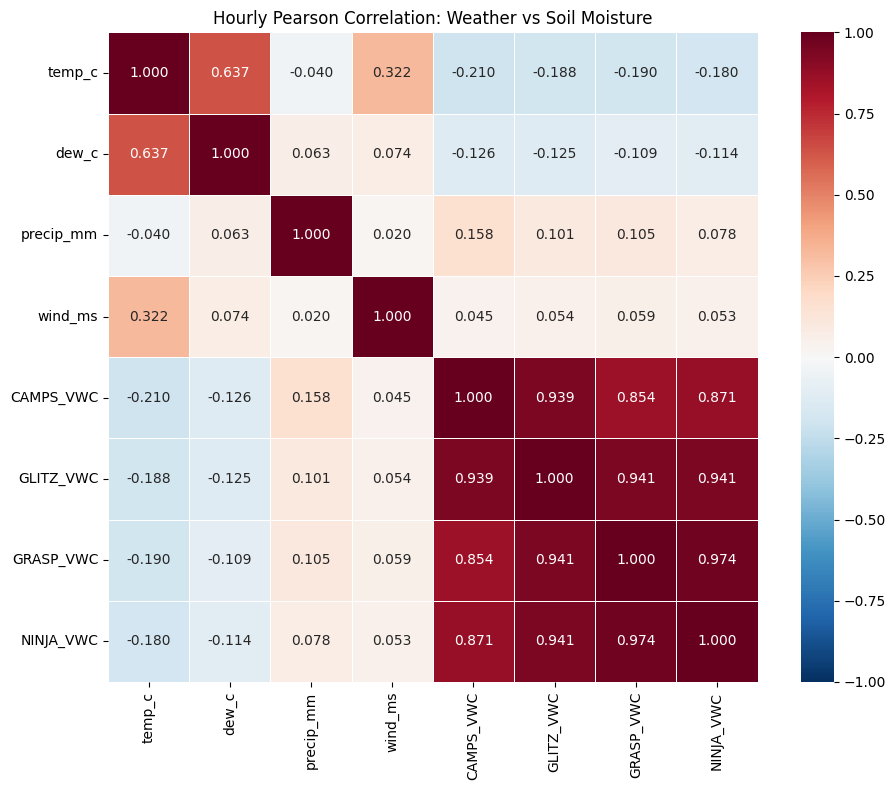

In [20]:
# Raw Hourly Pearson Correlation Matrix
corr_h = merged_h[weather_vars + sensor_vars].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_h, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Hourly Pearson Correlation: Weather vs Soil Moisture')
plt.tight_layout()
plt.show()

In [21]:
# Statistical significance table
results_h = []
for sv in sensor_vars:
    for wv in weather_vars:
        valid = merged_h[[sv, wv]].dropna()
        if len(valid) > 2:
            r, p = stats.pearsonr(valid[sv], valid[wv])
            results_h.append({'Sensor': sv, 'Weather': wv, 'r': round(r, 4),
                              'p-value': f'{p:.2e}', 'Sig': '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''})

results_h_df = pd.DataFrame(results_h)
print(results_h_df.to_string(index=False))

   Sensor   Weather       r  p-value Sig
CAMPS_VWC    temp_c -0.2099 1.92e-21 ***
CAMPS_VWC     dew_c -0.1260 1.45e-08 ***
CAMPS_VWC precip_mm  0.1579 6.49e-13 ***
CAMPS_VWC   wind_ms  0.0452 4.32e-02   *
GLITZ_VWC    temp_c -0.1879 2.01e-17 ***
GLITZ_VWC     dew_c -0.1252 1.78e-08 ***
GLITZ_VWC precip_mm  0.1013 4.33e-06 ***
GLITZ_VWC   wind_ms  0.0543 1.51e-02   *
GRASP_VWC    temp_c -0.1902 8.05e-18 ***
GRASP_VWC     dew_c -0.1086 1.07e-06 ***
GRASP_VWC precip_mm  0.1052 1.81e-06 ***
GRASP_VWC   wind_ms  0.0591 8.14e-03  **
NINJA_VWC    temp_c -0.1800 4.27e-16 ***
NINJA_VWC     dew_c -0.1142 2.88e-07 ***
NINJA_VWC precip_mm  0.0776 4.37e-04 ***
NINJA_VWC   wind_ms  0.0535 1.67e-02   *


In [22]:
# Hourly differencing: ΔVWC (hour-to-hour change)
for sv in sensor_vars:
    merged_h[f'{sv}_delta'] = merged_h[sv].diff()

delta_vars_h = [c for c in merged_h.columns if '_delta' in c]

print('=== Hourly ΔVWC vs Weather ===')
print(f'{"Sensor":<22} {"precip_mm":>12} {"temp_c":>12}')
print('-' * 48)
for dv in delta_vars_h:
    row = f'{dv:<22}'
    for wv in ['precip_mm', 'temp_c']:
        valid = merged_h[[dv, wv]].dropna()
        r, p = stats.pearsonr(valid[dv], valid[wv])
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
        row += f'{r:>9.4f}{sig:>3}'
    print(row)

print('\nNote: hourly ΔVWC shows near-zero correlation with same-hour precip.')
print('This is because soil moisture responds with a lag of several hours — see lagged analysis below.')

=== Hourly ΔVWC vs Weather ===
Sensor                    precip_mm       temp_c
------------------------------------------------
CAMPS_VWC_delta         -0.0268      0.0625 **
GLITZ_VWC_delta          0.0254      0.0256   
GRASP_VWC_delta         -0.0246      0.0270   
NINJA_VWC_delta          0.0059      0.0070   

Note: hourly ΔVWC shows near-zero correlation with same-hour precip.
This is because soil moisture responds with a lag of several hours — see lagged analysis below.


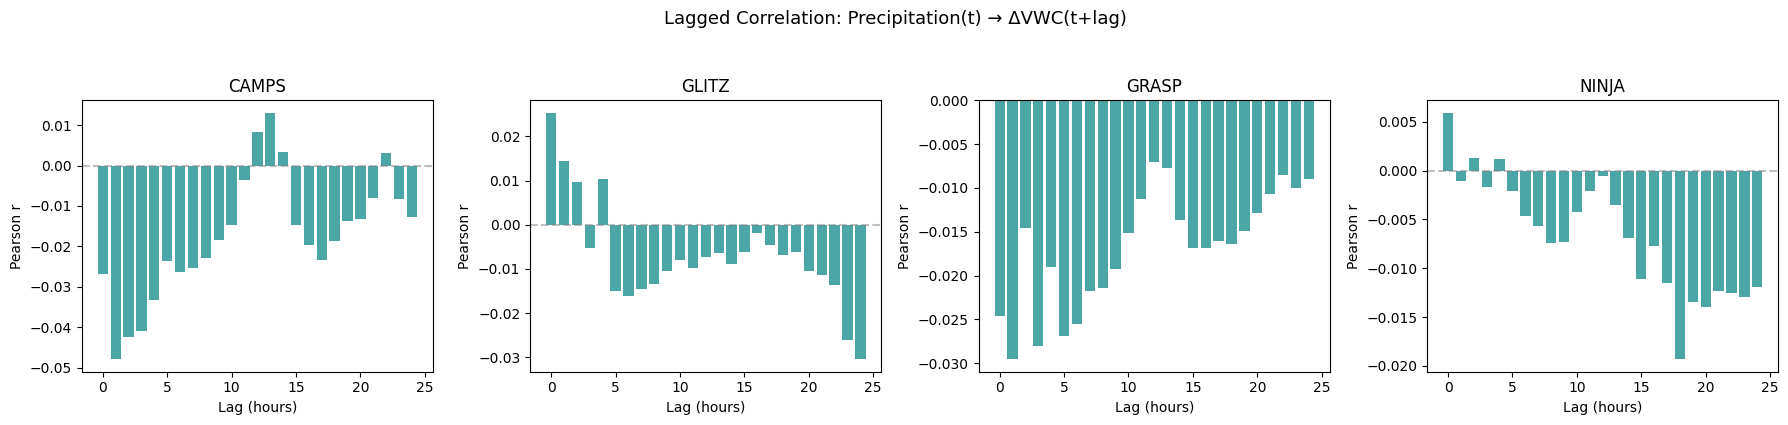

In [23]:
# Lagged ΔVWC: does precip at time t predict VWC *change* at time t+lag?
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
lag_hours = list(range(0, 25))

for i, sv in enumerate(sensor_vars):
    delta_col = f'{sv}_delta'
    lag_rs = []
    for lag in lag_hours:
        shifted_precip = merged_h['precip_mm'].shift(lag)
        valid = pd.DataFrame({'d': merged_h[delta_col], 'p': shifted_precip}).dropna()
        if len(valid) > 2:
            r, _ = stats.pearsonr(valid['d'], valid['p'])
        else:
            r = 0
        lag_rs.append(r)
    axes[i].bar(lag_hours, lag_rs, color='teal', alpha=0.7)
    axes[i].set_xlabel('Lag (hours)')
    axes[i].set_ylabel('Pearson r')
    axes[i].set_title(sv.replace('_VWC', ''))
    axes[i].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

fig.suptitle('Lagged Correlation: Precipitation(t) → ΔVWC(t+lag)', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

=== VWC vs Cumulative Precipitation (hourly windows) ===
Sensor          1h        6h        12h        24h        48h        72h        120h        168h        
-------------------------------------------------------------------------------------
CAMPS_VWC         0.1579   0.2391   0.3005   0.3850   0.4560   0.4779   0.4790   0.4212
GLITZ_VWC         0.1013   0.1682   0.2229   0.2960   0.3654   0.3984   0.4272   0.4229
GRASP_VWC         0.1052   0.1626   0.2033   0.2481   0.2860   0.3076   0.3257   0.3654
NINJA_VWC         0.0776   0.1273   0.1700   0.2262   0.2783   0.2993   0.3090   0.3505


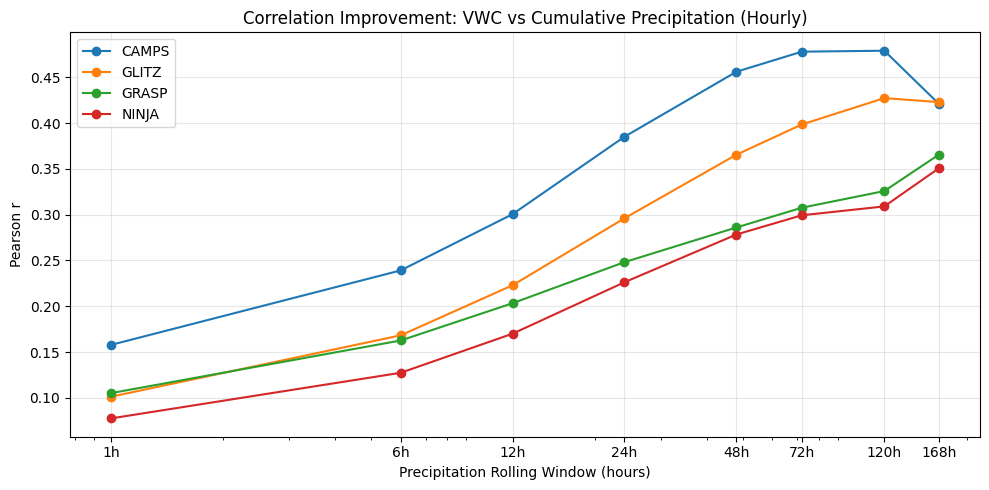

In [24]:
# Rolling Cumulative Precipitation vs VWC
windows_h = [1, 6, 12, 24, 48, 72, 120, 168]
for w in windows_h:
    if w > 1:
        merged_h[f'precip_{w}h'] = merged_h['precip_mm'].rolling(window=w, min_periods=1).sum()

rolling_results_h = {}
print('=== VWC vs Cumulative Precipitation (hourly windows) ===')
print(f'{"Sensor":<15}', ''.join(f'{w}h{" ":>8}' for w in windows_h))
print('-' * 85)
for sv in sensor_vars:
    row = f'{sv:<15}'
    rs = []
    for w in windows_h:
        col = 'precip_mm' if w == 1 else f'precip_{w}h'
        valid = merged_h[[sv, col]].dropna()
        r, _ = stats.pearsonr(valid[sv], valid[col])
        row += f'{r:>9.4f}'
        rs.append(r)
    rolling_results_h[sv] = rs
    print(row)

# Line plot
fig, ax = plt.subplots(figsize=(10, 5))
for sv in sensor_vars:
    ax.plot(windows_h, rolling_results_h[sv], marker='o', label=sv.replace('_VWC', ''))
ax.set_xlabel('Precipitation Rolling Window (hours)')
ax.set_ylabel('Pearson r')
ax.set_title('Correlation Improvement: VWC vs Cumulative Precipitation (Hourly)')
ax.set_xscale('log')
ax.set_xticks(windows_h)
ax.set_xticklabels([f'{w}h' for w in windows_h])
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

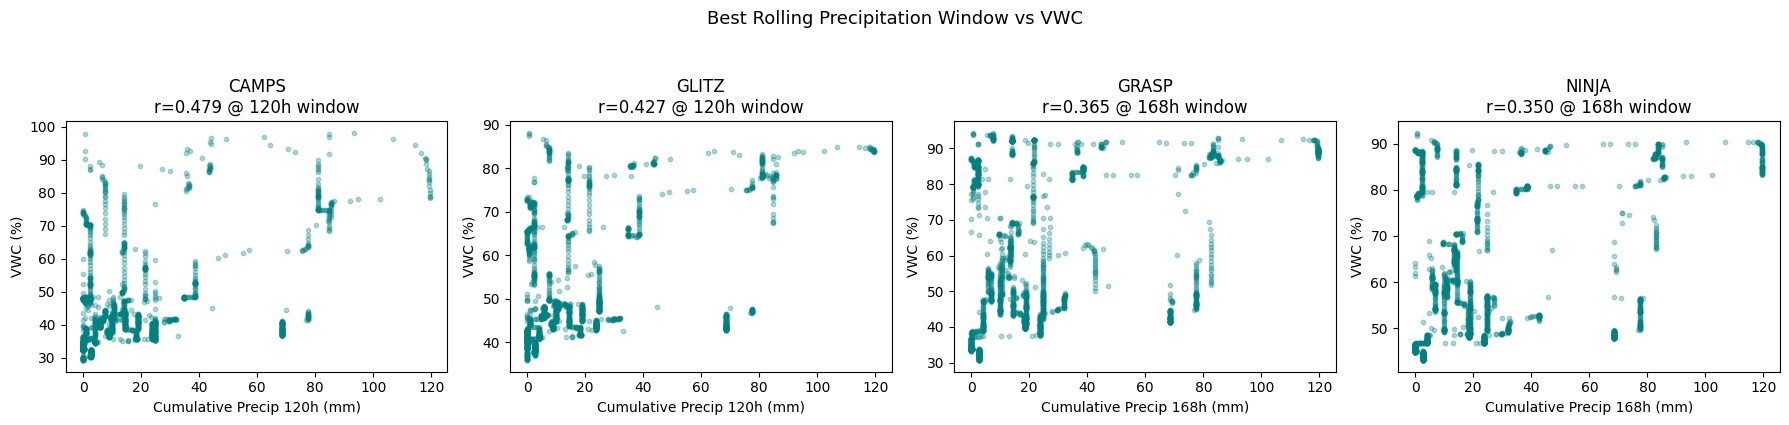

In [25]:
# Scatter: best rolling precip window vs VWC for each sensor
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, sv in enumerate(sensor_vars):
    # Find best window
    best_r, best_w = 0, 1
    for w in windows_h:
        col = 'precip_mm' if w == 1 else f'precip_{w}h'
        valid = merged_h[[sv, col]].dropna()
        r, _ = stats.pearsonr(valid[sv], valid[col])
        if abs(r) > abs(best_r):
            best_r, best_w = r, w
    col = 'precip_mm' if best_w == 1 else f'precip_{best_w}h'
    valid = merged_h[[sv, col]].dropna()
    axes[i].scatter(valid[col], valid[sv], alpha=0.3, s=10, color='teal')
    axes[i].set_xlabel(f'Cumulative Precip {best_w}h (mm)')
    axes[i].set_ylabel('VWC (%)')
    axes[i].set_title(f'{sv.replace("_VWC", "")}\nr={best_r:.3f} @ {best_w}h window')

fig.suptitle('Best Rolling Precipitation Window vs VWC', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()

In [26]:
# Comparison: Daily vs Hourly analysis
print('=== DAILY vs HOURLY Correlation Comparison ===')
print(f'{"":<12} {"--- Daily Analysis ---":>30} {"--- Hourly Analysis ---":>32}')
print(f'{"Sensor":<12} {"Raw":>8} {"ΔVWC":>8} {"Best Roll":>10} {"Raw":>10} {"ΔVWC":>8} {"Best Roll":>10}')
print('-' * 72)

# Daily values (from previous analysis, hardcoded for comparison)
daily_vals = {
    'CAMPS': {'raw': 0.4855, 'delta': 0.6208, 'roll': 0.6073},
    'GLITZ': {'raw': 0.4321, 'delta': 0.6268, 'roll': 0.6607},
    'GRASP': {'raw': 0.3875, 'delta': 0.5051, 'roll': 0.6487},
    'NINJA': {'raw': 0.3243, 'delta': 0.5840, 'roll': 0.5935},
}

for sv in sensor_vars:
    name = sv.replace('_VWC', '')
    d = daily_vals[name]

    # Hourly raw
    valid = merged_h[[sv, 'precip_mm']].dropna()
    r_raw_h, _ = stats.pearsonr(valid[sv], valid['precip_mm'])

    # Hourly delta
    dv = f'{sv}_delta'
    valid = merged_h[[dv, 'precip_mm']].dropna()
    r_delta_h, _ = stats.pearsonr(valid[dv], valid['precip_mm'])

    # Hourly best rolling
    best_r_h = 0
    for w in windows_h:
        col = 'precip_mm' if w == 1 else f'precip_{w}h'
        valid = merged_h[[sv, col]].dropna()
        r, _ = stats.pearsonr(valid[sv], valid[col])
        if abs(r) > abs(best_r_h): best_r_h = r

    print(f'{name:<12} {d["raw"]:>8.4f} {d["delta"]:>8.4f} {d["roll"]:>10.4f} {r_raw_h:>10.4f} {r_delta_h:>8.4f} {best_r_h:>10.4f}')

=== DAILY vs HOURLY Correlation Comparison ===
                     --- Daily Analysis ---          --- Hourly Analysis ---
Sensor            Raw     ΔVWC  Best Roll        Raw     ΔVWC  Best Roll
------------------------------------------------------------------------
CAMPS          0.4855   0.6208     0.6073     0.1579  -0.0268     0.4790
GLITZ          0.4321   0.6268     0.6607     0.1013   0.0254     0.4272
GRASP          0.3875   0.5051     0.6487     0.1052  -0.0246     0.3654
NINJA          0.3243   0.5840     0.5935     0.0776   0.0059     0.3505


## Hourly Analysis Results

### Why are hourly correlations *weaker* than daily?

This is counterintuitive but makes perfect physical sense:

**1. Temporal mismatch is worse at hourly scale.**
Rain at hour X doesn't affect soil moisture at hour X — it takes time to infiltrate. At hourly resolution, the lag matters much more. The lagged ΔVWC plot shows the response peaks several hours after rain, not instantaneously.

**2. Daily averaging acts as a natural low-pass filter.**
When you average to daily, you smooth out the sub-daily noise (sensor fluctuations, measurement jitter, brief dry spells between rain bands). This smoothing *increases* the signal-to-noise ratio. Hourly data is noisier.

**3. Shorter overlap period.**
The hourly weather data only covers Jan–Aug 2025 vs the sensor data starting in April–June. The overlap is ~85 days (June–August), compared to ~176 days in the daily analysis. Less data = less power to detect correlations, and the summer-only window removes the seasonal temperature/moisture signal.

### What the hourly data *does* reveal

- **Rolling cumulative precipitation still works**: 72–168h windows recover correlations to r ≈ 0.37–0.48, confirming the multi-day integration behavior
- **Lagged ΔVWC shows the infiltration delay**: the bar plots reveal *when* soil actually responds to rain (sensor-specific, typically 1–6 hours)
- **Wind speed and dew point emerge**: at hourly resolution, these show weak but significant correlations — they were invisible in the daily data

### Key Takeaway
Higher resolution ≠ better correlation. Daily aggregation was actually the better match for this analysis because soil moisture is a slow-response variable. The hourly data's value is in revealing the **temporal dynamics** (infiltration lag, response shape) rather than overall correlation strength.